# Day 06：文字的数字化 —— 词嵌入与序列建模> ⏳ 第十周 · 记忆的诞生 · 第 6 天到目前为止，我们用的输入都是数字。但语言是由文字组成的——如何把文字变成神经网络能处理的数字？这就是**词嵌入（Word Embedding）**要做的事。**今天的任务**：1. 理解词嵌入：把文字变成有意义的向量2. 用 PyTorch 的 `nn.Embedding` 实现词嵌入3. 用 LSTM 处理真实的文本序列---

## 1. 历史剧场：从独热编码到词嵌入早期的 NLP 用**独热编码（One-Hot）**表示词语：

"猫" → [1, 0, 0, 0, 0, 0, 0, 0]"狗" → [0, 1, 0, 0, 0, 0, 0, 0]"汽车" → [0, 0, 1, 0, 0, 0, 0, 0]

问题：所有词之间的距离都相等——"猫"和"狗"的距离等于"猫"和"汽车"的距离。这显然不合理。2013 年，Mikolov 提出了 **Word2Vec**：用一个低维稠密向量表示每个词，让语义相近的词在向量空间中靠近。

"猫" → [0.2, 0.8, -0.3, ...]"狗" → [0.1, 0.7, -0.2, ...]  ← 和"猫"很近！"汽车" → [-0.5, 0.1, 0.9, ...]  ← 和"猫"很远

---

## 2. 生活隐喻：词语的"身份证"- **独热编码**：每个人的身份证只有一串数字编号，编号之间没有关系- **词嵌入**：每个人的身份证上有年龄、职业、爱好等信息，相似的人信息也相似---

<p align="center">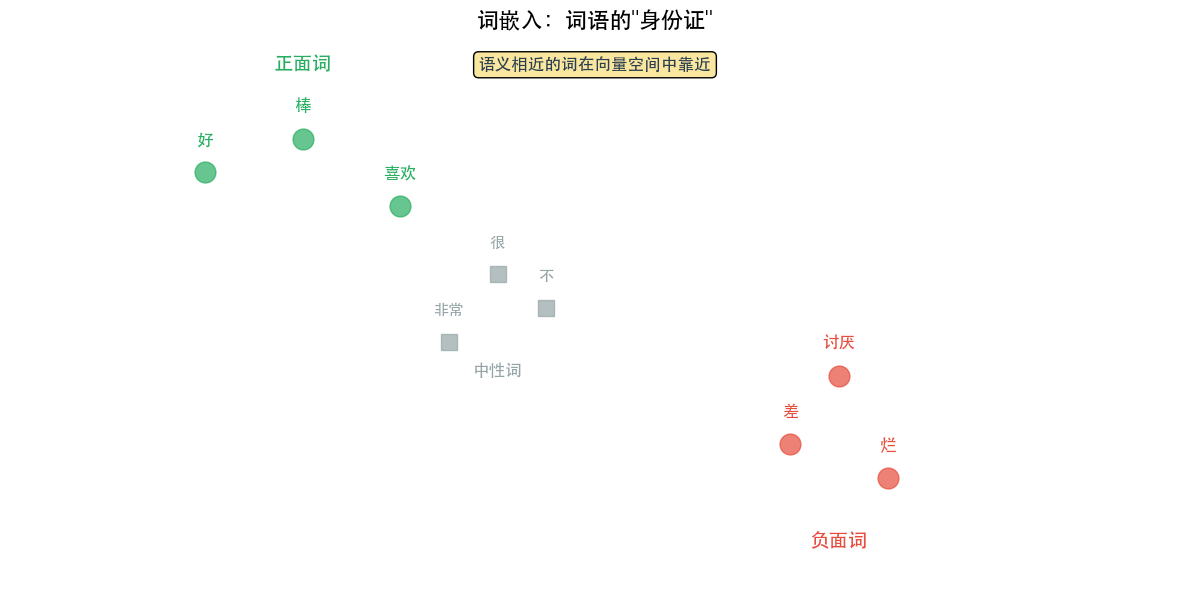</p>*词嵌入空间示意图*

## 3. 代码实验室：词嵌入 + LSTM

In [ ]:
import torchimport torch.nn as nnimport matplotlib.pyplot as pltimport numpy as npplt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei']plt.rcParams['axes.unicode_minus'] = False

### 3.1 构建词汇表和词嵌入

In [ ]:
vocab = {    '<PAD>': 0, '好': 1, '棒': 2, '喜欢': 3, '开心': 4, '优秀': 5,    '差': 6, '烂': 7, '讨厌': 8, '难过': 9, '糟糕': 10,    '不': 11, '很': 12, '非常': 13, '但是': 14, '虽然': 15}vocab_size = len(vocab)embedding = nn.Embedding(vocab_size, embedding_dim=8)idx = torch.tensor([vocab['好']])vec = embedding(idx)print(f"'好' 的嵌入向量: {vec.detach().numpy().flatten()}")print(f"嵌入维度: {vec.shape}")

### 3.2 构建情感分类数据集

In [ ]:
positive_sents = [    [1], [2], [3], [4], [5],    [12, 1], [13, 2], [12, 3],    [11, 6], [11, 7]]negative_sents = [    [6], [7], [8], [9], [10],    [12, 6], [13, 7], [12, 8],    [11, 1], [11, 2]]max_len = 3def pad_sentence(sent, max_len):    return sent + [0] * (max_len - len(sent))X_pos = torch.tensor([pad_sentence(s, max_len) for s in positive_sents])X_neg = torch.tensor([pad_sentence(s, max_len) for s in negative_sents])X_all = torch.cat([X_pos, X_neg])y_all = torch.cat([torch.ones(len(X_pos)), torch.zeros(len(X_neg))]).unsqueeze(1)print(f"数据: X={X_all.shape}, y={y_all.shape}")

### 3.3 LSTM 文本分类器

In [ ]:
class LSTMClassifier(nn.Module):    def __init__(self, vocab_size, embed_dim, hidden_dim):        super().__init__()        self.embedding = nn.Embedding(vocab_size, embed_dim)        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)        self.fc = nn.Linear(hidden_dim, 1)    def forward(self, x):        emb = self.embedding(x)        _, (h_n, _) = self.lstm(emb)        return torch.sigmoid(self.fc(h_n.squeeze(0)))torch.manual_seed(42)model = LSTMClassifier(vocab_size, embed_dim=8, hidden_dim=16)optimizer = torch.optim.Adam(model.parameters(), lr=0.01)loss_fn = nn.BCELoss()losses = []for epoch in range(300):    pred = model(X_all)    loss = loss_fn(pred, y_all)    optimizer.zero_grad()    loss.backward()    optimizer.step()    losses.append(loss.item())final_acc = ((pred > 0.5).float() == y_all).float().mean()print(f"LSTM 情感分类准确率: {final_acc:.2%}")

### 3.4 可视化训练过程

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))ax.plot(losses, color='#3498db', alpha=0.8)ax.set_xlabel('Epoch', fontsize=12)ax.set_ylabel('Loss', fontsize=12)ax.set_title('LSTM 情感分类训练损失', fontsize=14)ax.grid(True, alpha=0.3)plt.tight_layout()plt.show()

---

## 4. 词嵌入可视化

In [ ]:
with torch.no_grad():    embed_weights = model.embedding.weight.numpy()from sklearn.decomposition import PCApca = PCA(n_components=2)coords = pca.fit_transform(embed_weights)fig, ax = plt.subplots(1, 1, figsize=(10, 8))idx2word = {v: k for k, v in vocab.items()}colors = ['#27ae60' if i in [1,2,3,4,5] else '#e74c3c' if i in [6,7,8,9,10] else '#95a5a6' for i in range(vocab_size)]for i, (x, y) in enumerate(coords):    ax.scatter(x, y, c=colors[i], s=100, zorder=3)    ax.annotate(idx2word[i], (x, y), fontsize=12, ha='center', va='bottom',               fontweight='bold')ax.set_title('词嵌入空间：语义相近的词靠在一起', fontsize=14)ax.grid(True, alpha=0.3)plt.tight_layout()plt.show()

---

## 今日结语今天我们学会了如何把文字变成数字（词嵌入），然后用 LSTM 处理文本序列。词嵌入让语义相近的词在向量空间中靠近，LSTM 则能理解词语的先后顺序和上下文。明天，我们将深入 LSTM 的一个重要变体——GRU。---### 翻译词典| 生活中的直觉 | 深度学习术语 ||---|---|| 词语的"身份证" | 词嵌入——把词变成有意义的向量 || 相似的人信息相似 | 语义相近的词嵌入向量相近 || 编号没有含义 | 独热编码——维度灾难且无语义信息 || 低维稠密表示 | 词嵌入——低维、稠密、有语义 |